<center><h1> Predicción del precio de acciones Nvidia.</h1><br>

### Akira Cruz Marentes
### 31 de diciembre de 2025
</center>

## 1. Introducción

En este notebook se estudiará la serie de tiempo del valor de las acciones de la empresa tecnológica Nvidia, la cual ha tomado más importancia en los últimos años debido a la avance de la inteligencia artificial.

Se emplearan diversos modelos de predicción y se medirá el desempeño de cada uno.

## 2. Objetivos

### Objetivo principal

Construir un modelo que prediga el valor de cierre de las acciones de Nvidia

### Objetivo secundario
Relacionarse con el uso de librerías prophet, pmdarima y yfinance


## 3. Descripción del Dataset

Este dataset es una serie de tiempo que describe los valores del stock de Nvidia, extraído de yahoo finance utilizando la librería yfinance.

El dataset contiene 6 columnas y el indice se extiende hasta 1999

### Variables relevantes para el análisis:
- Open: Precio inicial.
- High: Precio máximo en el transcurso del día.
- Low: Precio mínimo en el transcurso del día.
- Close (objetivo): Precio final (cierre).
- Volume: Cantidad total de acciones de la empresa.


## 4. Exploración de Datos (EDA)

In [2]:
# Cargamos las librerías a utilizar

import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import yfinance as yf
import seaborn as sns
import pmdarima as pm
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller


c:\Users\Akira\Documents\Colab Notebooks\tsa\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Carga del objeto de yfinance del dataset de Nvidia.

ticker = yf.Ticker("NVDA")

# Cargamos los datos históricos con antigüedad máxima de 2 años.
historical_data = ticker.history(period="10y") 

# Información del dataset

print("Historical Data:")
print(historical_data.head())

print("\n Información del dataset:")
print(historical_data.info())

print("\n Estadísticas descriptivas:")
print(historical_data.describe())

print("\n Total de filas duplicadas:")
print(historical_data.duplicated().sum())

print("\n Total de valores faltantes por columna:")
print(historical_data.isnull().sum())

Historical Data:
                               Open      High       Low     Close     Volume  \
Date                                                                           
2016-01-11 00:00:00-05:00  0.723484  0.729094  0.711044  0.723972  409372000   
2016-01-12 00:00:00-05:00  0.736900  0.746901  0.731045  0.736168  469356000   
2016-01-13 00:00:00-05:00  0.741778  0.746657  0.712995  0.713727  481672000   
2016-01-14 00:00:00-05:00  0.699091  0.707385  0.678602  0.699335  600236000   
2016-01-15 00:00:00-05:00  0.671284  0.679333  0.649818  0.661283  841452000   

                           Dividends  Stock Splits  
Date                                                
2016-01-11 00:00:00-05:00        0.0           0.0  
2016-01-12 00:00:00-05:00        0.0           0.0  
2016-01-13 00:00:00-05:00        0.0           0.0  
2016-01-14 00:00:00-05:00        0.0           0.0  
2016-01-15 00:00:00-05:00        0.0           0.0  

 Información del dataset:
<class 'pandas.core.fram

In [4]:
# Modificamos el índice para que aparezca solo la fecha 
historical_data.reset_index(inplace = True)
historical_data["Date"] = historical_data["Date"].dt.date 
historical_data.set_index("Date", inplace=True)    

# Quitamos las variables que no utilizaremos.
historical_data.drop(["Stock Splits", "Dividends"], axis = 1, inplace = True)
historical_data

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-11,0.723484,0.729094,0.711044,0.723972,409372000
2016-01-12,0.736900,0.746901,0.731045,0.736168,469356000
2016-01-13,0.741778,0.746657,0.712995,0.713727,481672000
2016-01-14,0.699091,0.707385,0.678602,0.699335,600236000
2016-01-15,0.671284,0.679333,0.649818,0.661283,841452000
...,...,...,...,...,...
2026-01-02,189.839996,192.929993,188.259995,188.850006,148240500
2026-01-05,191.759995,193.630005,186.149994,188.119995,183529700
2026-01-06,190.520004,192.169998,186.820007,187.240005,176862600


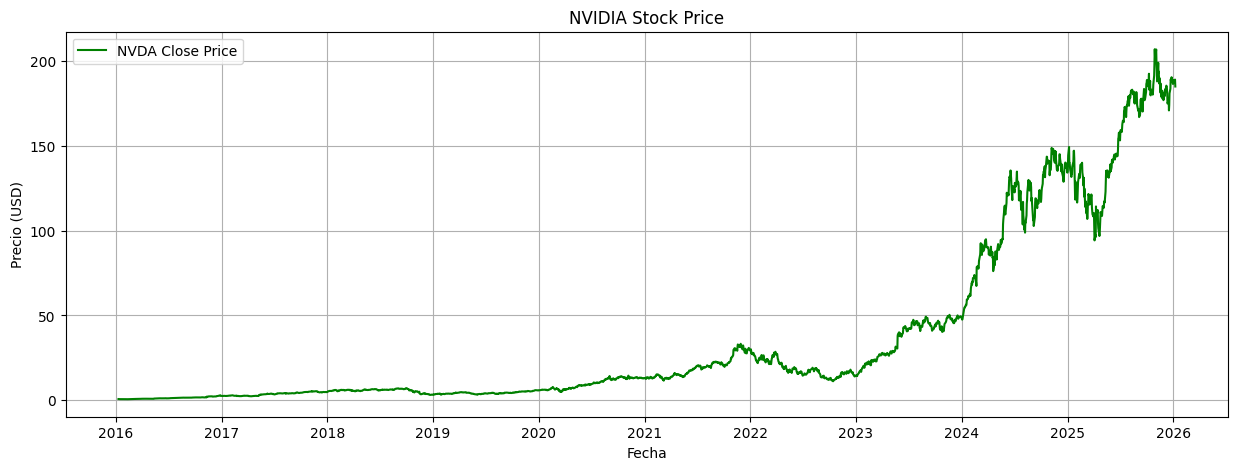

In [5]:
# Graficamos la variable objetivo.

plt.figure(figsize=(15,5))
plt.plot(historical_data["Close"], label = "NVDA Close Price", color ="green")
plt.title("NVIDIA Stock Price")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.legend()
plt.grid()
plt.show()

### Aplicando el test ADF de estacionaridad:

In [6]:
def adf_test(series):
    test_results = adfuller(series)
    print('ADF Statistic: ', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print(f"\t{thres}: {adf_stat:.2f}")

In [7]:
adf_test(historical_data["Close"])

ADF Statistic:  1.8326844714594495
P-Value:  0.9984116854169514
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57


$H_0$ (Hipótesis nula): La serie no es estacionaria

$H_1$ (Hipótesis alternativa): La serie es estacionaria

Estableciendo un valor de significancia ($\alpha$) igual a 0.05, tenemos que $p>\alpha$ por lo que $H_0$ se confirma con un 99% de certeza

ADF Statistic:  -17.993860127255704
P-Value:  2.748590243982259e-30
Critical Values:
	1%: -3.43
	5%: -2.86
	10%: -2.57


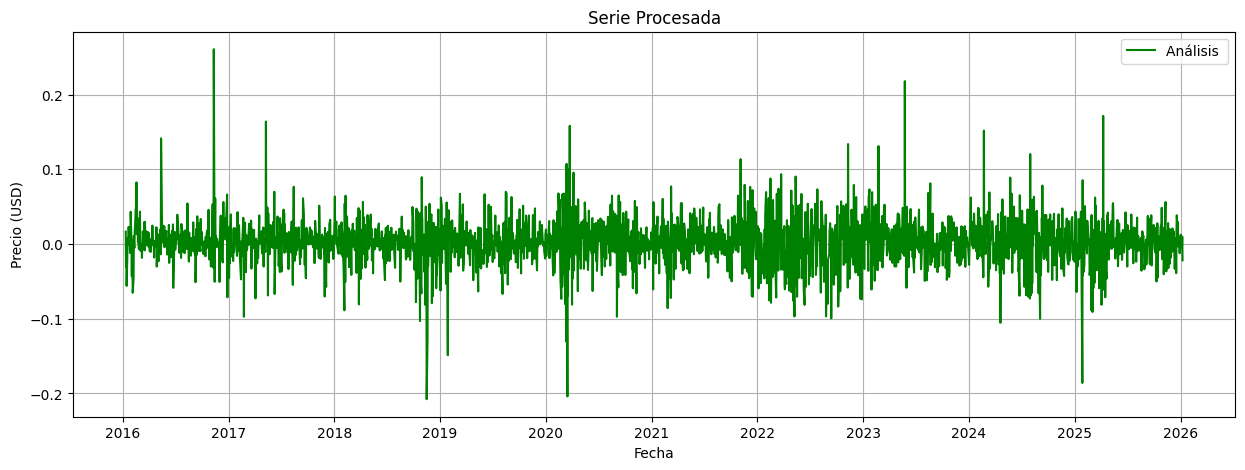

In [8]:
data_log_diff = np.log(historical_data["Close"]).diff()

adf_test(data_log_diff[1:])

plt.figure(figsize=(15,5))
plt.plot(data_log_diff, label = "Análisis ", color ="green")
plt.xlabel("Fecha")
plt.title("Serie Procesada")
plt.ylabel("Precio (USD)")
plt.legend()
plt.grid()
plt.show()

$H_0$ (Hipótesis nula): La serie no es estacionaria

$H_1$ (Hipótesis alternativa): La serie es estacionaria

Estableciendo un valor de significancia $\alpha=0.05$ , tenemos que $p<\alpha$ por lo que $H_0$ se rechaza con más del 99% de certeza.

Un procesamiento similar se aplicará en el apartado del modelo ARIMA, en los demás modelos no es necesario tener la serie estacionaria

## 5. Modelo predictivo

Utilizaremos varios modelos, donde evaluaremos el desempeño en la predicción y rapidez de su ejecución.

Para evaluar los modelos, utilizaremos los últimos 30 días como datos de prueba

### Red Neuronal (LSTM)

Utilizaremos una red neuronal del tipo Long-Short Term Memory (LSTM), el cual es ampliamente usada en el análisis de series temporales debido a su capacidad de captar solo los patrones relevantes y captar relaciones no lineales.

In [9]:
# Separación de datos de entrenamiento y prueba
# En esta sección se hace así ya que después utilizaremos una ventana deslizante.

days = 30
n = int(len(historical_data))- 5
split = int(n-days)
training_len = split + 5

train_data = historical_data.iloc[:training_len]
test_data = historical_data.iloc[training_len:]

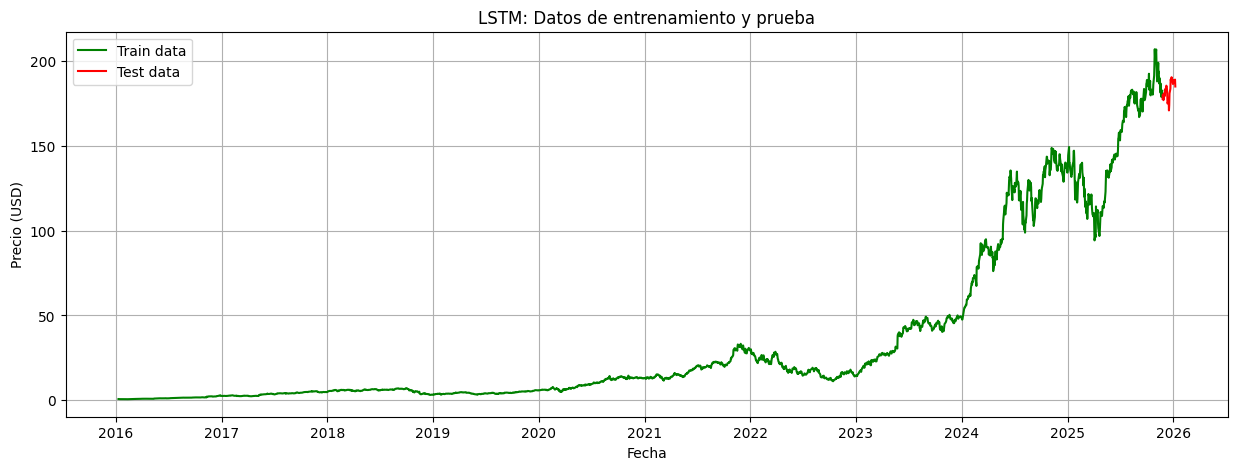

In [10]:
# Gráfica de los datos de entrenamiento y prueba

plt.figure(figsize=(15,5))
plt.plot(historical_data.index[:training_len], train_data["Close"], color = "g", label = "Train data")
plt.plot(historical_data.index[training_len:], test_data["Close"], color = "r", label = "Test data")
plt.grid()
plt.legend()
plt.title("LSTM: Datos de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

In [11]:
# Ingienería de variables

close_minus = historical_data["Close"][:-1].values
close_minus = np.insert(close_minus, 0, 0)

historical_data["Close Minus"] = close_minus

In [12]:
# Preparación de los datos 

from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X = historical_data.drop(["Close", "High", "Low"], axis=1).values
y = historical_data['Close'].values.reshape(-1,1)

X_s = scaler_X.fit_transform(X)
y_s = scaler_y.fit_transform(y)

# Función de ventana temporal

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X)-seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

# Ventana temporal de 5 días
seq_len = 5
X_seq, y_seq = create_sequences(X_s, y_s, seq_len)

# División train/test (walk-forward es preferible)
split = int(len(X_seq)-days)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [13]:
from tensorflow import keras

# Creación del modelo

model = keras.Sequential([
    keras.layers.LSTM(128, return_sequences=False, input_shape=(seq_len, X.shape[1])),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mae')

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
]
history = model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=32, callbacks=callbacks)

model.summary()



c:\Users\Akira\Documents\Colab Notebooks\tsa\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Epoch 1/20


c:\Users\Akira\Documents\Colab Notebooks\tsa\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1002 - val_loss: 0.1531 - learning_rate: 0.0010
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0216 - val_loss: 0.2422 - learning_rate: 0.0010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0232 - val_loss: 0.1611 - learning_rate: 0.0010
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0208 - val_loss: 0.2979 - learning_rate: 0.0010
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0209 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0197 - val_loss: 0.1601 - learning_rate: 5.0000e-04
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0188 - val_loss: 0.2080 - learning_rate: 5.0000e-04
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0191 - val_loss: 0.1812 - learning_rate: 5.0000e-04
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0185 - val_loss: 0.1424 - learning_rate: 5.0000e-04
Epoch 10/20
70/70 ━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,717 (889.52 KB)

 Trainable params: 75,905 (296.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 151,812 (593.02 KB)

In [14]:
# Predecir e inversa
y_pred_s = model.predict(X_test)
RNN_predictions = scaler_y.inverse_transform(y_pred_s)
y_true = scaler_y.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


### ARIMA

Utilizaremos el modelo ARIMA como el estándar de comparación, ya que es un modelo básico en el análisis de series temporales.

Para la implementación, usaremos la función AutoArima de la librería pmdarima, la cual calcula los mejores hiperparámetros según los datos.

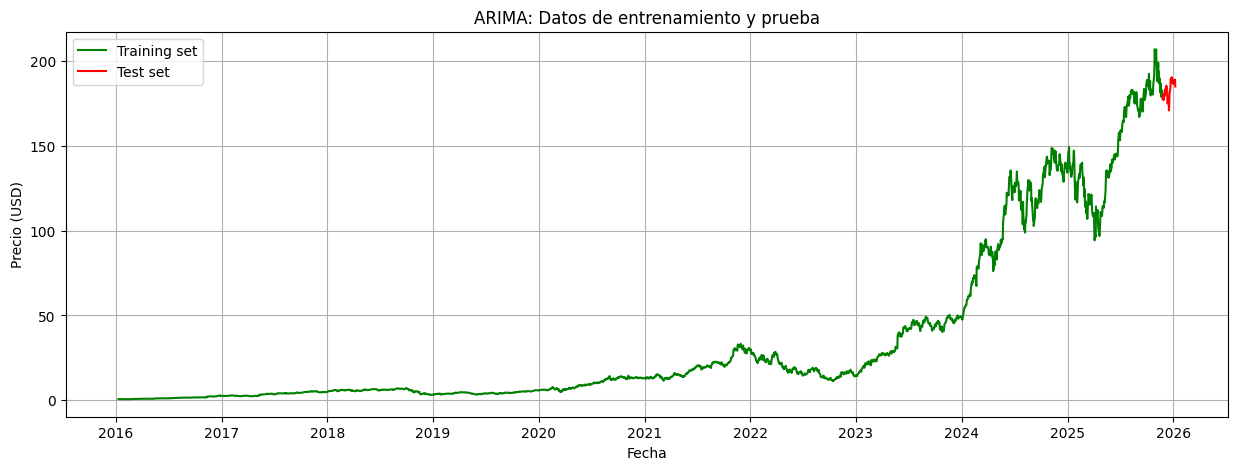

In [15]:
from pmdarima.model_selection import train_test_split

# División de datos de entrenamiento y prueba

train, test = train_test_split(historical_data["Close"].values, test_size=30)

plt.figure(figsize=(15,5))
plt.plot(historical_data.index[:training_len], train, label="Training set", color="g")
plt.plot(historical_data.index[training_len:], test, label="Test set", color="r")
plt.grid()
plt.legend()
plt.title("ARIMA: Datos de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

In [16]:
from pmdarima.pipeline import Pipeline
from pmdarima.preprocessing import BoxCoxEndogTransformer



pipeline = Pipeline([
    ('boxcox', BoxCoxEndogTransformer()),        # Preparación de datos
    ('arima', pm.AutoARIMA(seasonal=True, m=5,  # Modelo
                           stepwise=True,
                           suppress_warnings=True,
                           trace=True,
                           approximation=True,
                           information_criterion="aic",
                           error_action="ignore"))
])


pipeline.fit(train)
pipeline.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=-10883.520, Time=1.80 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=-10876.877, Time=0.27 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=-10887.791, Time=0.55 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=-10886.684, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=-10866.087, Time=0.15 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=-10889.772, Time=0.14 sec
 ARIMA(1,1,0)(0,0,1)[5] intercept   : AIC=-10887.790, Time=0.28 sec
 ARIMA(1,1,0)(1,0,1)[5] intercept   : AIC=-10885.967, Time=1.35 sec
 ARIMA(2,1,0)(0,0,0)[5] intercept   : AIC=-10891.156, Time=0.26 sec
 ARIMA(2,1,0)(1,0,0)[5] intercept   : AIC=-10889.158, Time=0.66 sec
 ARIMA(2,1,0)(0,0,1)[5] intercept   : AIC=-10889.141, Time=0.41 sec
 ARIMA(2,1,0)(1,0,1)[5] intercept   : AIC=-10887.401, Time=1.35 sec
 ARIMA(3,1,0)(0,0,0)[5] intercept   : AIC=-10889.168, Time=0.60 sec
 ARIMA(2,1,1)(0,0,0)[5] intercept   : AIC=-10889.164, Time=0.85 sec
 ARIM

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2484
Model:               SARIMAX(2, 1, 0)   Log Likelihood                5449.578
Date:                Thu, 08 Jan 2026   AIC                         -10891.156
Time:                        14:26:01   BIC                         -10867.887
Sample:                             0   HQIC                        -10882.706
                               - 2484                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0020      0.001      3.669      0.000       0.001       0.003
ar.L1         -0.0742      0.014     -5.262      0.000      -0.102      -0.047
ar.L2          0.0369      0.017      2.226      0.026       0.004       0.069
sigma2         0.0007   9.45e-06     76.874      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              6156.46
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                             0.13
Prob(H) (two-sided):                  0.19   Kurtosis:                        10.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
# Predicción
n_periods = int(len(test))
Arima_predictions, conf_int = pipeline.predict(n_periods=n_periods, return_conf_int=True)

c:\Users\Akira\Documents\Colab Notebooks\tsa\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['approximation']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


### Prophet

Prophet es un modelo de predicción creado por el equipo de ciencia de datos de Facebook.

In [18]:
# Preparación de datos 

prophet_data = historical_data.reset_index()
prophet_data.rename(columns={"Date" : "ds", "Close" : "y"}, inplace=True)


prophet_data

,ds,Open,High,Low,y,Volume,Close Minus
0,2016-01-11,0.723484,0.729094,0.711044,0.723972,409372000,0.000000
1,2016-01-12,0.736900,0.746901,0.731045,0.736168,469356000,0.723972
2,2016-01-13,0.741778,0.746657,0.712995,0.713727,481672000,0.736168
3,2016-01-14,0.699091,0.707385,0.678602,0.699335,600236000,0.713727
4,2016-01-15,0.671284,0.679333,0.649818,0.661283,841452000,0.699335
...,...,...,...,...,...,...,...
2509,2026-01-02,189.839996,192.929993,188.259995,188.850006,148240500,186.500000
2510,2026-01-05,191.759995,193.630005,186.149994,188.119995,183529700,188.850006
2511,2026-01-06,190.520004,192.169998,186.820007,187.240005,176862600,188.119995
2512,2026-01-07,188.570007,191.369995,186.559998,189.110001,153543200,187.240005


Última fecha del training set:
2025-11-24
Primera fecha del test set: 
2025-11-25


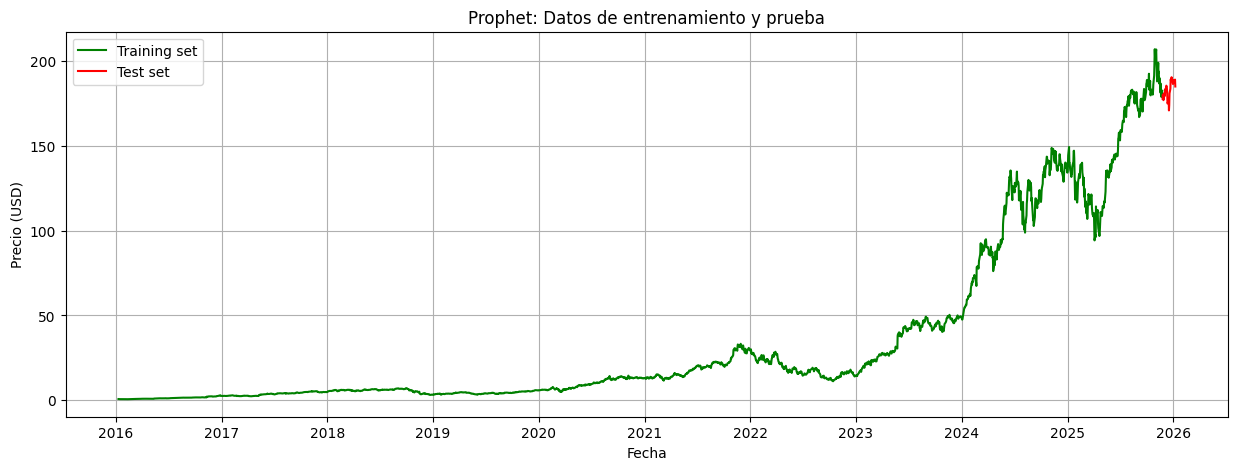

In [19]:
# Separación de datos

prophet_test = prophet_data.iloc[-30:]
prophet_train = prophet_data.iloc[:-30]

print(f"Última fecha del training set:\n{prophet_train["ds"].iloc[-1]}")
print(f"Primera fecha del test set: \n{prophet_test["ds"].iloc[0]}")

plt.figure(figsize=(15,5))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Training set", color="g")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Test set", color="r")
plt.grid()
plt.legend()
plt.title("Prophet: Datos de entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.show()

In [20]:
# Construcción del modelo

Regressors = ["Open", "Volume", "Close Minus"]


model_prophet= Prophet(yearly_seasonality=True,
                        weekly_seasonality=True,
                        daily_seasonality=False)
for reg in Regressors:
    model_prophet.add_regressor(reg)

model_prophet.fit(prophet_train[["ds","y"] + Regressors])

14:26:02 - cmdstanpy - INFO - Chain [1] start processing
14:26:03 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
# Predicción
Forecast_Prophet = model_prophet.predict(prophet_test[["ds"] + Regressors])

Descomposición de la serie temporal


Componentes de periodicidad:



C:\Users\Akira\AppData\Local\Temp\ipykernel_6776\226336293.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  Prophet_components.show()


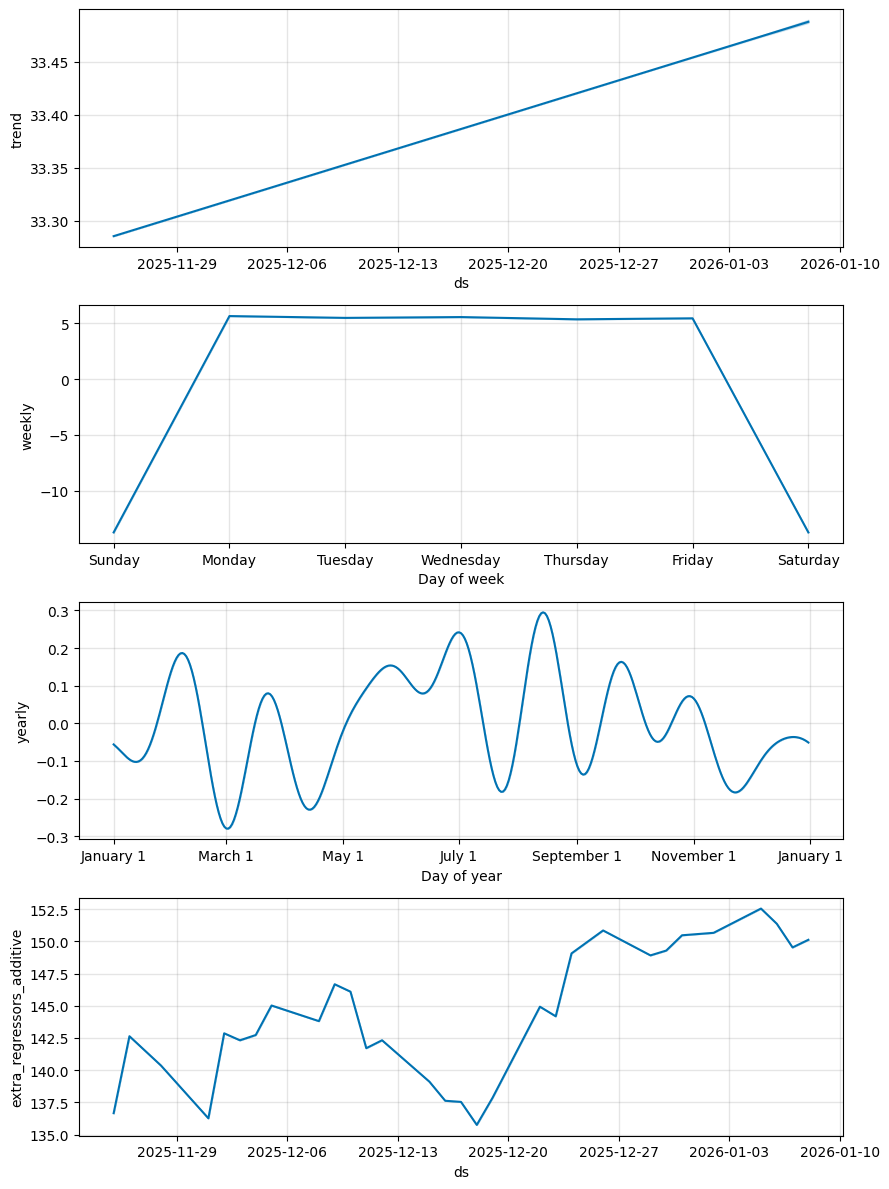

In [22]:
print("Componentes de periodicidad:\n")
Prophet_components = model_prophet.plot_components(Forecast_Prophet)
Prophet_components.show()

In [23]:
# Verificación de la cantidad de predicciónes
Prophet_predictions = Forecast_Prophet["yhat"].values
Prophet_predictions.shape

(30,)

## 6. Evaluación de Modelos

               MAE  RMSE  MAPE
Red Neuronal  5.02  6.03  0.03
ARIMA         7.14  8.37  0.04
Prophet       2.09  2.76  0.01



[]

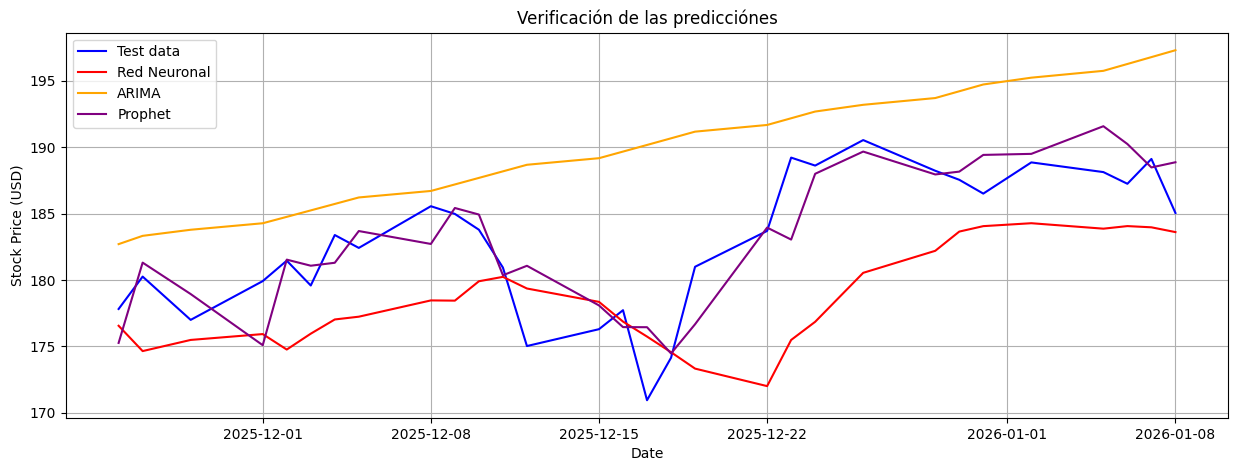

In [29]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


rmse_rnn = root_mean_squared_error(y_true=y_true, y_pred=RNN_predictions)
mae_rnn = mean_absolute_error(y_true=y_true, y_pred=RNN_predictions)
mape_rnn = mean_absolute_percentage_error(y_true=y_true, y_pred=RNN_predictions)

rmse_arima = root_mean_squared_error(y_true=y_true, y_pred=Arima_predictions)
mae_arima = mean_absolute_error(y_true=y_true, y_pred=Arima_predictions)
mape_arima = mean_absolute_percentage_error(y_true=y_true, y_pred=Arima_predictions)

rmse_prophet = root_mean_squared_error(y_true=y_true, y_pred=Prophet_predictions)
mae_prophet = mean_absolute_error(y_true=y_true, y_pred=Prophet_predictions)
mape_prophet = mean_absolute_percentage_error(y_true=y_true, y_pred=Prophet_predictions)


# DataFrame con las métricas de cada modelo

resultados = pd.DataFrame(data={"MAE": [mae_rnn, mae_arima, mae_prophet], 
                                "RMSE": [rmse_rnn, rmse_arima, rmse_prophet],
                                "MAPE": [mape_rnn, mape_arima, mape_prophet]},  
                                index=["Red Neuronal", "ARIMA", "Prophet"])

resultados = resultados.round(2) # Imprimir los valores con solo 2 decimales

print(f"{resultados}\n")


x_plot = historical_data.index[training_len:]
plt.figure(figsize=(15,5))
# plt.plot(historical_data.index[:training_len], train_data["Close"], color = "g", label = "Test data")
plt.plot(x_plot, test_data["Close"], color = "b", label = "Test data")
plt.plot(x_plot, RNN_predictions, color = "r", label = "Red Neuronal")
plt.plot(x_plot, Arima_predictions, color = "orange", label = "ARIMA")
plt.plot(x_plot, Prophet_predictions, color = "purple", label = "Prophet")


plt.grid()
plt.legend()
plt.title("Verificación de las predicciónes")
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.plot()

### Análisis de Residuos:

La media de los residuos deben de ser 0, de otra manera, el modelo puede estar sesgado.

Se puede ajustar el modelo añadiendo el sesgo a la predicción, o emplendo métodos para encontrar los hiperparámetros óptimos

Residuos de cada modelo
   RNN Residues  ARIMA Residues  Prophet Residues
0      1.263077       -4.884848          2.555895
1      5.609711       -3.068497         -1.052541
2      1.510223       -6.786949         -1.945926
3      3.989044       -4.356789          4.825587
4      6.693817       -3.299518         -0.077443


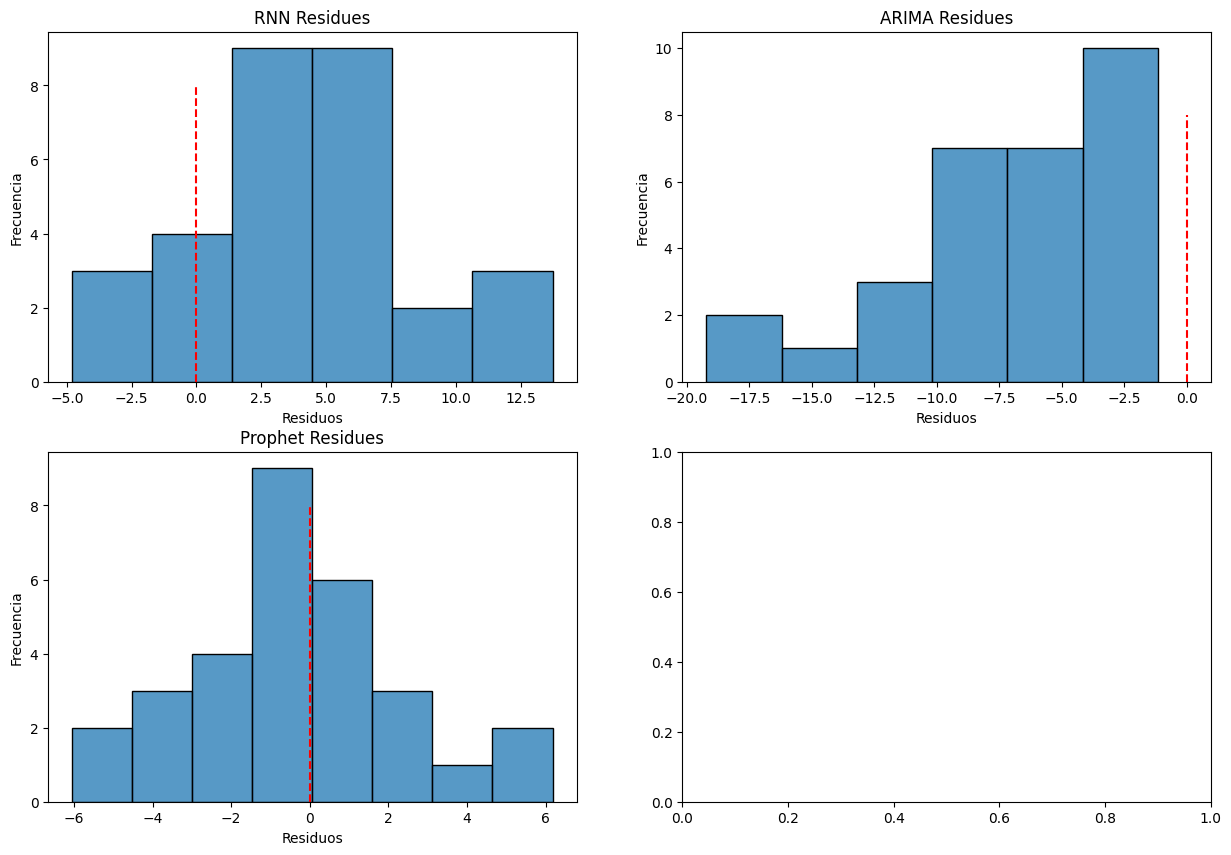

In [25]:
# DataFrame con la información de los residuos de cada modelo

Residuos = pd.DataFrame(columns=["RNN Residues", "ARIMA Residues", "Prophet Residues"])


Residuos["RNN Residues"] = np.ravel(y_true) - np.ravel(RNN_predictions)
Residuos["ARIMA Residues"] = np.ravel(y_true) - np.ravel(Arima_predictions)
Residuos["Prophet Residues"] = np.ravel(y_true) - np.ravel(Prophet_predictions)

print(f"Residuos de cada modelo\n{Residuos.head()}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=Residuos["RNN Residues"], ax=axes[0,0])
axes[0,0].set_title("RNN Residues")
axes[0,0].set_xlabel("Residuos")
axes[0,0].set_ylabel("Frecuencia")
axes[0,0].plot([0,0], [0,8], color = "red", linestyle="--")


sns.histplot(data=Residuos["ARIMA Residues"], ax=axes[0,1])
axes[0,1].set_title("ARIMA Residues")
axes[0,1].set_xlabel("Residuos")
axes[0,1].set_ylabel("Frecuencia")
axes[0,1].plot([0,0], [0,8], color = "red", linestyle="--")


sns.histplot(data=Residuos["Prophet Residues"], ax=axes[1,0])
axes[1,0].set_title("Prophet Residues")
axes[1,0].set_xlabel("Residuos")
axes[1,0].set_ylabel("Frecuencia")
axes[1,0].plot([0,0], [0,8], color = "red", linestyle="--")



Vemos que el único modelo con su media en 0 es Prophet, Arima tiene un sesgo positivo y la Red Neuronal uno negativo.

La correlación entre los residuos demuestra que hay patrones que el modelo no adaptó bien y es algo que podemos arreglar al construir el modelo nuevamente (periodicidad).

Un método cuantitativo para ver la correlación entre los residuos es la prueba estadística Ljung-Box.

$H_0$ : No hay correlación entre los residuos.

$H_1$ : Hay correlación entre los residuos.


In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print(f"RNN\n:{acorr_ljungbox(Residuos['RNN Residues'], return_df=True)}\n")
print(f"ARIMA\n:{acorr_ljungbox(Residuos['ARIMA Residues'], return_df=True)}\n")
print(f"Prophet\n:{acorr_ljungbox(Residuos['Prophet Residues'], return_df=True)}\n")



RNN
:     lb_stat     lb_pvalue
1  15.989260  6.370286e-05
2  21.536997  2.105235e-05
3  21.882335  6.901362e-05
4  23.962147  8.128238e-05
5  30.470900  1.191226e-05
6  42.568962  1.419437e-07

ARIMA
:     lb_stat  lb_pvalue
1  17.504120   0.000029
2  26.393578   0.000002
3  28.967810   0.000002
4  29.037452   0.000008
5  31.189366   0.000009
6  37.565591   0.000001

Prophet
:     lb_stat  lb_pvalue
1   0.082542   0.773882
2   0.399468   0.818948
3   6.263401   0.099475
4  10.369693   0.034640
5  10.471377   0.062929
6  10.960042   0.089619



Cada fila es cada lag de los residuos.

Tomando $\alpha = 0.05$

RNN y ARIMA: $p<\alpha$ por lo que sí hay correlación entre los residuos

Prophet: $p>\alpha$ por lo que no hay correlación entre los residuos

### Aclaraciones

Es importante recalcar que no todos los modelos "juegan en la misma cancha", ya que ARIMA es univariado (solo estudia la variable objetivo) y en cambio, la Red Neuornal y Prophet son multi-variable (Close, Open, Close Minus y Volume) lo cual les da ventaja.

La ventaja que tiene Prophet es que es muy directo de usar, a comparación de la red neuronal, que al no tener un conocimiento tan profundo de estas, es más difícil de armar una red óptima. Similarmente, con la función AutoArima tardaba al rededor de 20 minutos entrenando con la periodicidad 252 (diaria), por lo que se optó por usar una periodicidad semanal (5).

El desempeño inferior de la red LSTM puede deberse a una arquitectura simple y a la falta de una búsqueda exhaustiva de hiperparámetros, lo cual queda como trabajo futuro.

## 7. Conclusiones
- **Peor modelo**: ARIMA               (4% de error)
- **Modelo intermedio**: Red Neuronal  (3% de error)
- **Mejor modelo** : Prophet           (1% de error)

De acuerdo a las métricas usadas, el modelo que mejor se desempeñó fue el Prophet, además que es rápido en entrenar y tiene una arquitectura sencilla.






